In [4]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Period

In [7]:
iyear = 2000
fyear = 2024
nx=10;ny=10
dom = 'GRp'

# SF & RF Data

In [18]:
RF = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/RF_monsum_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['RF']
RF = RF.rename({'TIME': 'time'})

SF = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/SF_monsum_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['SF']
SF = SF.rename({'TIME': 'time'})


#Compute Total Rainfall
TF = RF + SF

#Domain & period def
TF = TF[:,ny:-ny,nx:-nx].sel(time=slice(str(iyear),str(fyear)))

# MONTHLY MEAN

In [19]:
TF = TF.groupby('time.month').mean('time', skipna=True)
TF = TF.mean(dim=['Y','X'], skipna=True)

SF = SF.groupby('time.month').mean('time', skipna=True)
SF = SF.mean(dim=['Y','X'], skipna=True)

RF = RF.groupby('time.month').mean('time', skipna=True)
RF = RF.mean(dim=['Y','X'], skipna=True)

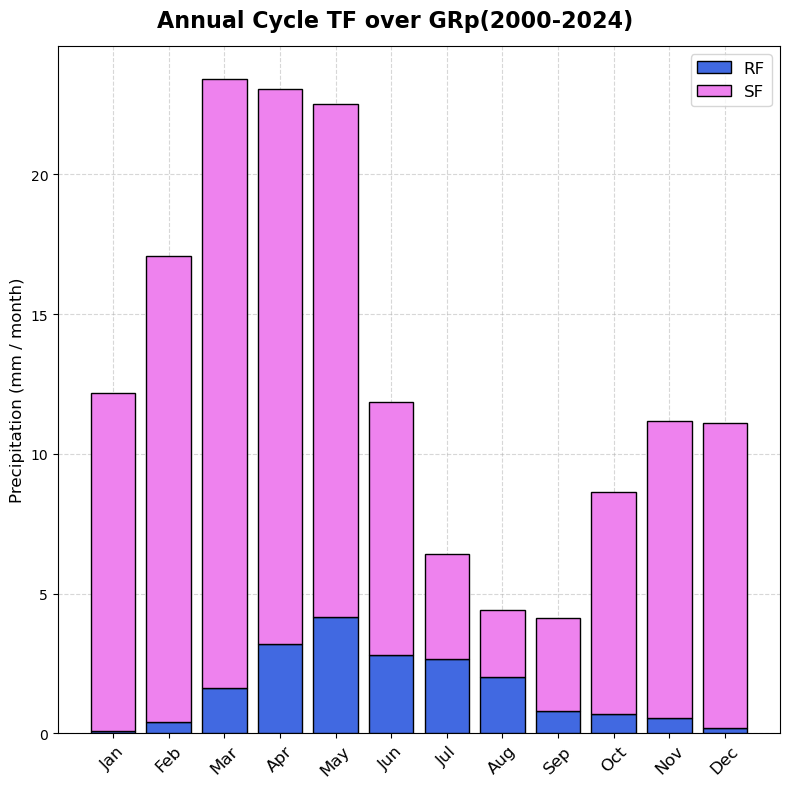

In [33]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
unite = 'mm / month'

fig, ax = plt.subplots(figsize=(8,8))

da_sf = SF
da_rf = RF

ax.bar(
    da_rf['month'], da_rf.values,
    label=f'RF', color='royalblue', edgecolor='black', zorder=5
)

ax.bar(
    da_sf['month'], da_sf.values,
    bottom=da_rf.values,
    label=f'SF', color='violet', edgecolor='black', zorder=5
)

# --- axes
ax.set_xticks(range(1,13))
ax.set_xticklabels(months, rotation=45, fontsize=12)

ax.set_ylabel(f'Precipitation ({unite})', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

# --- legend
ax.legend(fontsize=12)

fig.suptitle(f'Annual Cycle TF over {dom}({iyear}-{fyear})', fontsize=16, weight='bold')

plt.tight_layout()
plt.show()

# Comparing with t2m

In [38]:
t2m = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/TTZ_monmean_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['TTZ'][:,0,:,:] # 0 = first pressure level at surface
t2m = t2m.rename({'TIME': 'time'})

In [39]:
t2m = t2m.groupby('time.month').mean('time', skipna=True)
t2m = t2m.mean(dim=['Y','X'], skipna=True)

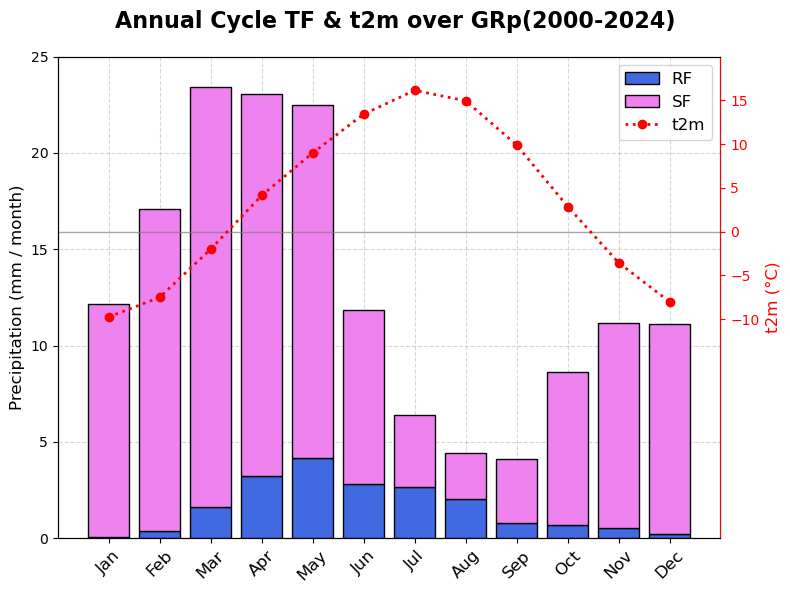

In [49]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
unite = 'mm / month'

fig, ax = plt.subplots(figsize=(8,6))

ax2 = ax.twinx()  # axe droit
# mettre l'axe droit en red
ax2.tick_params(axis='y', colors='red')
ax2.yaxis.label.set_color('red')
ax2.spines['right'].set_color('red')

da_sf = SF
da_rf = RF
da_t2m = t2m

ax.bar(
    da_rf['month'], da_rf.values,
    label=f'RF', color='royalblue', edgecolor='black', zorder=5
)

ax.bar(
    da_sf['month'], da_sf.values,
    bottom=da_rf.values,
    label=f'SF', color='violet', edgecolor='black', zorder=5
)

ax2.plot(
        da_t2m['month'], da_t2m.values,
        marker='o', linestyle=':',
        color='red',
        label=f't2m',
        linewidth=2
    )

ax2.axhline(y=0, color='grey', linestyle='-', linewidth=1, alpha = 0.7, zorder = 0)

# --- axes
ax.set_xticks(range(1,13))
ax.set_xticklabels(months, rotation=45, fontsize=12)

ax.set_ylabel(f'Precipitation ({unite})', fontsize=12)
ax2.set_ylabel('t2m (°C)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

# mettre la t2m au dessus de precipitation
ax.set_ylim(bottom=0, top=25) # axe gauche
ax2.set_ylim(bottom=-35, top=20) # axe droit

ticks = np.arange(-40, 20, 5)
ticks_filtered = ticks[(ticks >= -10) & (ticks <= 20)]
ax2.set_yticks(ticks_filtered)

ticks = np.arange(0, 30, 5)
ticks_filtered = ticks[(ticks >= 0) & (ticks <= 25)]
ax.set_yticks(ticks_filtered)

# --- legend
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, fontsize=12)

fig.suptitle(f'Annual Cycle TF & t2m over {dom}({iyear}-{fyear})', fontsize=16, weight='bold')

plt.tight_layout()
plt.show()

# Only on Glacierized area